In [3]:
import os
import warnings
import numpy as np
import xarray as xr
import pandas as pd
import proplot as pplt
from pysr import PySRRegressor
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100})

In [4]:
FILEDIR = '/global/cfs/cdirs/m4334/sferrett/monsoon-discovery/data/interim'
x  = xr.open_dataarray(f'{FILEDIR}/cape.nc').isel(time=slice(0,5),lat=slice(0,5),lon=slice(0,5)).values.ravel()
y  = xr.open_dataarray(f'{FILEDIR}/bl.nc').isel(time=slice(0,5),lat=slice(0,5),lon=slice(0,5)).values.ravel()
df = pd.DataFrame({'x':x,'y':y})

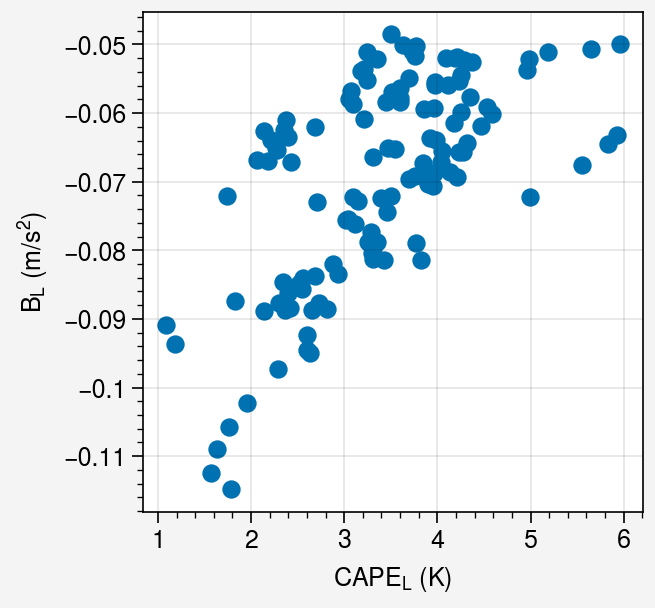

In [5]:
fig,ax = pplt.subplots(nrows=1,ncols=1)
ax.format(xlabel='$CAPE_L$ (K)',ylabel='$B_L$ (m/s$^2$)')
ax.scatter(df['x'],df['y'])
pplt.show()

In [6]:
opcomplexity = {
    '+':1,
    '*':1,
    '-':1,
    '/':3,
    '^':3,
    'sin':4,
    'cos':4,
    'exp':4,
    'log':4,
    'sqrt':4}

model = PySRRegressor(
    niterations=3,
    populations=3,
    population_size=10, 
    tournament_selection_n=2,
    binary_operators=['+','-','*','/'], 
    unary_operators=['sin','cos','exp','log','sqrt'],
    complexity_of_operators=opcomplexity,
    complexity_of_variables=2,
    loss='loss(x, y) = (x - y)^2',
    maxsize=10, 
    model_selection='best', 
    random_state=42,
    multithreading=False,
    procs=0)

In [ ]:
model.fit(df[['x']].values,df['y'].values)
print(model)

Compiling Julia backend...


In [81]:
equations = model.equations_
print(equations[['equation','complexity','loss','score']].head(10))

best  = model.get_best()
eqstr = best['sympy_format']
ypred = best['lambda_format'](df[['x']].values)

           equation  complexity          loss      score
0         2.0052867           1  1.160741e+01   0.000000
1     x0 * 3.002581           4  3.999990e+00   0.355117
2  (x0 * 3.0) + 2.0           6  2.080669e-14  16.444897


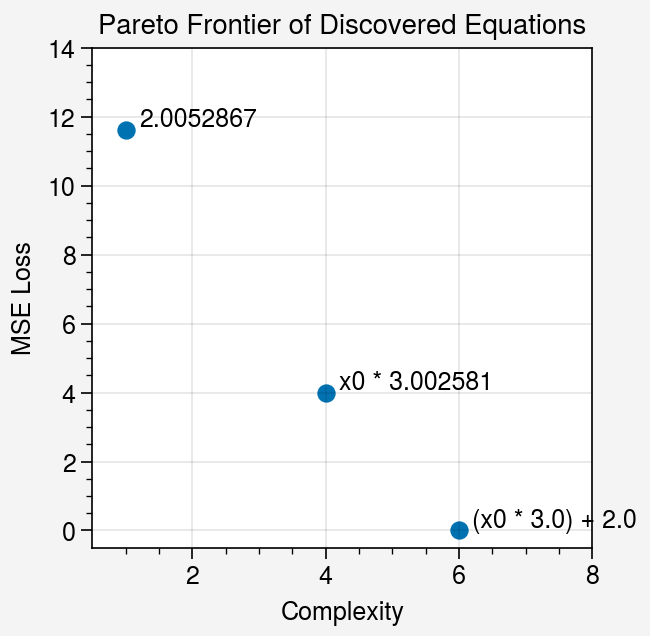

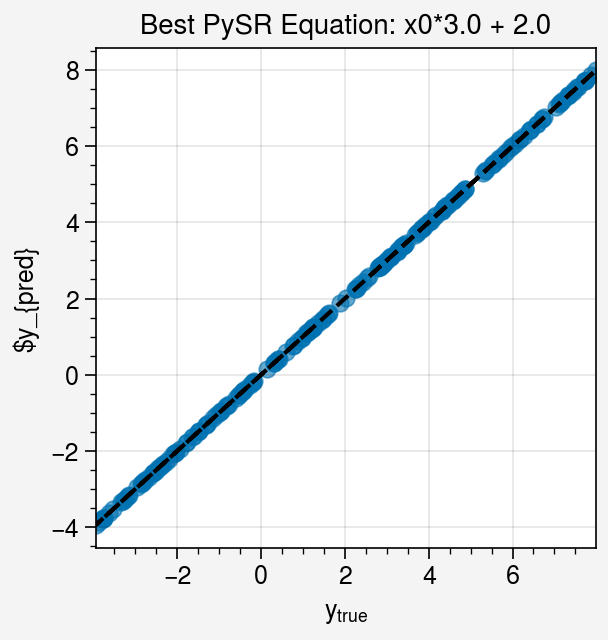

In [82]:
fig,ax = pplt.subplots(nrows=1,ncols=1)
ax.format(title='Pareto Frontier of Discovered Equations',
          xlabel='Complexity',xlim=(0.5,8),ylabel='MSE Loss',ylim=(-0.5,14))
ax.scatter(equations['complexity'],equations['loss'])
for i,row in equations.iterrows():
    ax.text(row['complexity']+0.2,row['loss']+0.1,row['equation'])
pplt.show()

fig,ax = pplt.subplots(nrows=1,ncols=1)
ax.format(title=f'Best PySR Equation: {eqstr}',grid=True,xlabel='$y_{true}$',ylabel='$y_{pred}$')
ax.plot(df['y'],df['y'],color='k',linestyle='--')
ax.scatter(df['y'],ypred,alpha=0.6)
pplt.show()